In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from collections import Counter


In [ ]:
df = pd.read_csv("../datasets/final_clean_jobs_dataset.csv")
df.head()

In [ ]:
df["required_skills"].head()

In [7]:
all_skills = []

for skill_text in df["required_skills"]:

    skills = str(skill_text).split(",")
    skills = [s.strip() for s in skills]
    all_skills.extend(skills)

In [8]:
print(all_skills[:20])

['Tableau', 'PyTorch', 'Kubernetes', 'Linux', 'NLP', 'Deep Learning', 'AWS', 'Mathematics', 'Python', 'Docker', 'Kubernetes', 'Deep Learning', 'Java', 'Hadoop', 'NLP', 'Scala', 'SQL', 'Linux', 'Python', 'MLOps']


In [9]:
skill_counts = Counter(all_skills)

In [10]:


skills_df = pd.DataFrame(
    skill_counts.items(),
    columns = ["Skill","Count"]
)
skills_df = skills_df.sort_values(by = "Count", ascending = False)

In [11]:
skills_df.head(20)

,Skill,Count
8,Python,4450
13,SQL,3407
21,TensorFlow,3022
2,Kubernetes,3009
12,Scala,2794
1,PyTorch,2777
3,Linux,2705
19,Git,2631
10,Java,2578
20,GCP,2442


In [ ]:
#save skills in Data frame to csv
skills_df.to_csv("../outputs/top_skills.csv", index=False)

In [13]:
#top 10 skills
top10 = skills_df.head(10)
top10

,Skill,Count
8,Python,4450
13,SQL,3407
21,TensorFlow,3022
2,Kubernetes,3009
12,Scala,2794
1,PyTorch,2777
3,Linux,2705
19,Git,2631
10,Java,2578
20,GCP,2442


In [ ]:
#create top 10 bar chart
plt.figure(figsize=(10,6))
plt.bar(top10["Skill"], top10["Count"])

plt.xticks(rotation=45)
plt.title("Top 10 In-Demand Skills in Job Postings")
plt.tight_layout()

plt.savefig("../outputs/top10_skills_bar_chart.png")

plt.show()

In [ ]:
#top 20 skills
top20 = skills_df.head(20)

top20

,Skill,Count
8,Python,4450
13,SQL,3407
21,TensorFlow,3022
2,Kubernetes,3009
12,Scala,2794
1,PyTorch,2777
3,Linux,2705
19,Git,2631
10,Java,2578
20,GCP,2442


In [ ]:
#create top 10 bar chart
plt.figure(figsize=(12,6))

plt.bar(
    top20["Skill"],
    top20["Count"]
)

plt.xticks(rotation=60)

plt.title("Top 20 Skills")

plt.tight_layout()

plt.savefig(
    "../outputs/top20_skills_bar_chart.png"
)

plt.show()

In [ ]:
# pie chart top 10 skills
plt.figure(figsize=(8,8))
plt.pie(
    top10["Count"],
    labels=top10["Skill"],
    autopct="%1.1f%%",
    startangle=140
)
plt.title("Top 10 In-Demand Skills Distribution")
plt.tight_layout()
plt.savefig("../outputs/top10_skills_pie_chart.png")
plt.show()

In [28]:
#create Ai skills Demand list

ai_skills = [
    "Python",
    "Machine Learning",
    "Deep Learning",
    "Tensorflow",
    "Pytorch",
    "NLP",
    "Computer Vision",
    "AWS",
    "Azure",
    "Spark",
    "SQL",
    "Mathematics",
    "R",
    "PyTorch",
    "MLOps"
]

In [29]:
ai_skills_df = skills_df[skills_df["Skill"].isin(ai_skills)]

#View
ai_skills_df

,Skill,Count
8,Python,4450
13,SQL,3407
1,PyTorch,2777
16,R,2311
17,Computer Vision,2284
5,Deep Learning,2189
14,MLOps,2164
23,Spark,2155
4,NLP,2145
18,Azure,2144


In [ ]:

#Skills by Country
df["company_location"].value_counts().head()


In [35]:
# top countries with most job postings
top_countries = (
    df["company_location"]
    .value_counts()
    .head(5)
    .index
)

In [36]:
#Country-wise skills:
for country in top_countries:

    country_df = df[
        df["company_location"] == country
    ]

    skills = []

    for skill_text in country_df["required_skills"]:

        skills.extend(
            [s.strip() for s in str(skill_text).split(",")]
        )

    print("\n", country)

    print(
        Counter(skills).most_common(10)
    )


 Germany
[('Python', 240), ('SQL', 184), ('Kubernetes', 176), ('TensorFlow', 170), ('Git', 156), ('GCP', 155), ('Linux', 151), ('PyTorch', 146), ('Scala', 146), ('Tableau', 136)]

 Denmark
[('Python', 244), ('SQL', 173), ('Kubernetes', 167), ('PyTorch', 162), ('Scala', 149), ('TensorFlow', 147), ('Linux', 141), ('Hadoop', 136), ('GCP', 133), ('Java', 131)]

 Canada
[('Python', 233), ('SQL', 172), ('TensorFlow', 167), ('PyTorch', 158), ('Kubernetes', 157), ('Git', 150), ('Computer Vision', 140), ('Scala', 134), ('Java', 131), ('Linux', 125)]

 France
[('Python', 229), ('SQL', 179), ('Kubernetes', 162), ('Scala', 146), ('PyTorch', 143), ('Hadoop', 135), ('TensorFlow', 133), ('Linux', 131), ('R', 129), ('Computer Vision', 125)]

 Austria
[('Python', 231), ('TensorFlow', 169), ('SQL', 166), ('Scala', 155), ('Kubernetes', 154), ('Hadoop', 141), ('R', 137), ('Linux', 133), ('PyTorch', 132), ('Java', 132)]


In [52]:
def categorize_job(title):

    title = str(title).lower()

    if "data scientist" in title:
        return "Data Science"

    elif "data analyst" in title:
        return "Data Analytics"

    elif "data engineer" in title:
        return "Data Engineering"

    elif "machine learning engineer" in title:
        return "Machine Learning"

    elif "machine learning researcher" in title:
        return "Machine Learning"

    elif "deep learning engineer" in title:
        return "Deep Learning"

    elif "nlp engineer" in title:
        return "NLP"

    elif "computer vision engineer" in title:
        return "Computer Vision"

    elif "ml ops engineer" in title:
        return "MLOps"

    elif "robotics engineer" in title:
        return "Robotics"

    elif "autonomous systems engineer" in title:
        return "Robotics"

    elif "research scientist" in title:
        return "AI Research"

    elif "ai research scientist" in title:
        return "AI Research"

    elif "ai software engineer" in title:
        return "AI Engineering"

    elif "ai specialist" in title:
        return "AI Engineering"

    elif "ai architect" in title:
        return "AI Leadership"

    elif "ai consultant" in title:
        return "AI Leadership"

    elif "ai product manager" in title:
        return "AI Leadership"

    elif "head of ai" in title:
        return "AI Leadership"

    else:
        return "Other"

In [46]:
df["job_category"] = df["job_title"].apply(categorize_job)

In [48]:
df[["job_title", "job_category"]].head(20)

,job_title,job_category
0,AI Research Scientist,Other
1,AI Software Engineer,Other
2,AI Specialist,Other
3,NLP Engineer,NLP Engineer
4,AI Consultant,Other
5,AI Architect,Other
6,Principal Data Scientist,Data Scientist
7,NLP Engineer,NLP Engineer
8,Data Analyst,Data Analyst
9,AI Software Engineer,Other


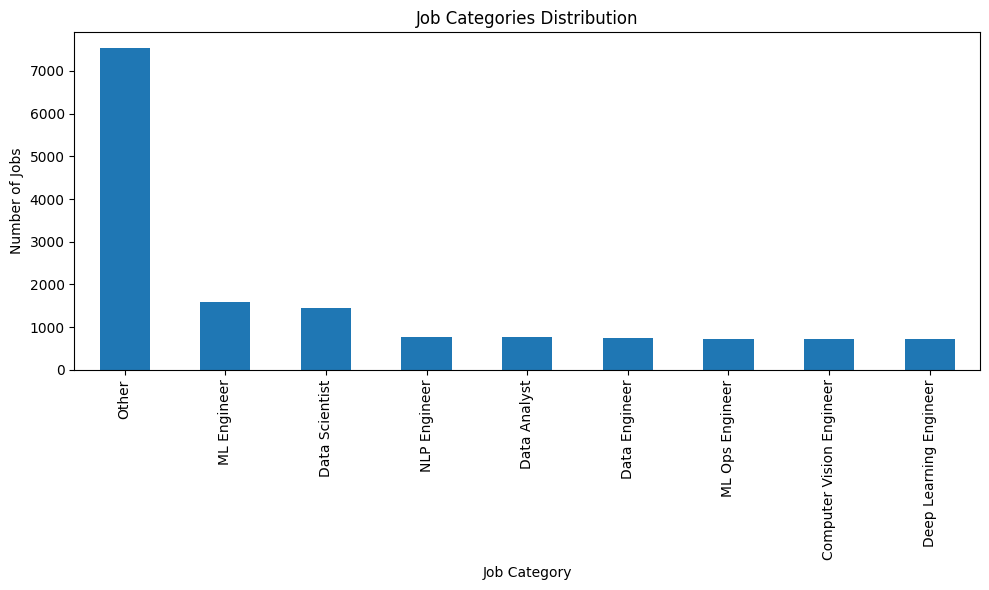

In [53]:
import matplotlib.pyplot as plt

category_counts = df["job_category"].value_counts()

plt.figure(figsize=(10,6))
category_counts.plot(kind="bar")

plt.title("Job Categories Distribution")
plt.xlabel("Job Category")
plt.ylabel("Number of Jobs")

plt.tight_layout()

plt.savefig("../outputs/job_category_distribution.png")

plt.show()

In [54]:
df["job_category"].value_counts()

job_category
Other                       7529
ML Engineer                 1580
Data Scientist              1454
NLP Engineer                 762
Data Analyst                 759
Data Engineer                749
ML Ops Engineer              725
Computer Vision Engineer     724
Deep Learning Engineer       718
Name: count, dtype: int64

In [ ]:
from collections import Counter

for category in df["job_category"].unique():

    temp = df[df["job_category"] == category]

    all_skills = []

    for skill_text in temp["required_skills"]:

        skills = str(skill_text).split(",")

        skills = [s.strip() for s in skills]

        all_skills.extend(skills)

    top_skills = Counter(all_skills).most_common(5)

    print("\n", category)
    print(top_skills)

In [55]:
rows = []

for category in df["job_category"].unique():

    temp = df[df["job_category"] == category]

    all_skills = []

    for skill_text in temp["required_skills"]:

        skills = [s.strip() for s in str(skill_text).split(",")]

        all_skills.extend(skills)

    top_skills = Counter(all_skills).most_common(10)

    for skill, count in top_skills:

        rows.append([category, skill, count])

category_skill_df = pd.DataFrame(
    rows,
    columns=["Job_Category", "Skill", "Count"]
)

category_skill_df.to_csv(
    "../outputs/skills_by_job_category.csv",
    index=False
)

In [51]:
sorted(df["job_title"].unique())

['AI Architect',
 'AI Consultant',
 'AI Product Manager',
 'AI Research Scientist',
 'AI Software Engineer',
 'AI Specialist',
 'Autonomous Systems Engineer',
 'Computer Vision Engineer',
 'Data Analyst',
 'Data Engineer',
 'Data Scientist',
 'Deep Learning Engineer',
 'Head of AI',
 'ML Ops Engineer',
 'Machine Learning Engineer',
 'Machine Learning Researcher',
 'NLP Engineer',
 'Principal Data Scientist',
 'Research Scientist',
 'Robotics Engineer']

In [56]:
df.to_csv(
    "../datasets/final_clean_jobs_dataset.csv",
    index=False
)